## 1. Introduction

### 1.1 Background

Thyroid disorders are among the most common endocrine diseases worldwide and can significantly affect metabolism, cardiovascular health, growth, and overall well-being. The two main forms of thyroid dysfunction are **hyperthyroidism**, caused by excessive thyroid hormone production, and **hypothyroidism**, resulting from insufficient hormone production. Accurate diagnosis often relies on a combination of patient history, clinical assessment, and laboratory tests such as Thyroid Stimulating Hormone (TSH), Triiodothyronine (T3), and Thyroxine (T4).

Recent advances in machine learning have demonstrated considerable potential for supporting healthcare decision-making by identifying complex patterns within clinical data. This project explores the application of supervised machine learning techniques to multiclass thyroid disease classification.

### 1.2 Problem Statement

Accurate differentiation between hyperthyroidism, hypothyroidism, and normal thyroid function remains challenging because these conditions often exhibit overlapping clinical characteristics. Given the availability of routinely collected clinical and laboratory data, this project investigates whether supervised machine learning models can accurately classify patients into the three thyroid disease categories and identify the most effective predictive approach.

### 1.3 Key Questions

This project seeks to answer the following questions:

1. Can machine learning accurately classify patients into **Hyperthyroidism**, **Hypothyroidism**, and **Normal thyroid function** using routinely collected clinical and laboratory data?
2. Which clinical and laboratory features are most informative for distinguishing between thyroid conditions?
3. Which supervised machine learning algorithm provides the best predictive performance for multiclass thyroid disease classification?
4. How does class imbalance influence model performance across the three thyroid classes?
5. Which thyroid conditions are most frequently misclassified, and what factors may contribute to these errors?


### 1.4 Project Objective

The primary objective of this project is to develop and evaluate multiclass machine learning models capable of classifying patients into **Hyperthyroidism**, **Hypothyroidism**, or **Normal thyroid function**. In addition, the project aims to compare the performance of multiple classification algorithms and identify the clinical and laboratory features that contribute most to accurate thyroid disease prediction.


### 1.5 Success Metrics

Model performance will be assessed primarily using the Macro F1-score, which provides a balanced evaluation across all thyroid classes. Supporting metrics will include Balanced Accuracy, class-specific Precision, Recall, F1-score, and Confusion Matrices to provide a comprehensive assessment of predictive performance. Overall Accuracy will be reported for completeness but will not be the primary criterion for model selection due to the imbalanced class distribution.

## 2. Data Understanding

 This section introduces the dataset, examines its structure, and performs an initial quality assessment to identify potential issues that may require attention during data preparation. The goal is to establish a clear understanding of the available data before conducting exploratory analysis.

### 2.1 Import Libraries

The project relies on several Python libraries for data manipulation, visualization, statistical analysis, and machine learning. Importing these libraries at the beginning of the notebook ensures that all required tools are available for the subsequent analysis.

In [2]:

# Import Libraries

# Core Libraries
import warnings
import joblib
from pathlib import Path

import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
from scipy import stats
from scipy.stats import chi2_contingency, kruskal

# Machine Learning - Preprocessing
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif, f_classif

# Machine Learning - Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Boosting Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Model Interpretation
from sklearn.inspection import permutation_importance

# =====================================================
# Notebook Settings
# =====================================================

warnings.filterwarnings("ignore")

sns.set_theme(
    style="whitegrid",
    palette="viridis",
    context="notebook"
)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

print("Libraries imported successfully.")

Libraries imported successfully.


### 2.2 Load Dataset

The next step is to load the thyroid disease dataset into a Pandas DataFrame for inspection and analysis.


In [3]:
# Load dataset
df = pd.read_csv("data/thyroid.csv")

# Display dataset dimensions
print(f"Dataset Shape: {df.shape}")

# Display the first five records
df.head()

Dataset Shape: (7200, 22)


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,class
0,0.7300,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0.0006,0.0150,0.1200,0.0820,0.1460,3
1,0.2400,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0003,0.0300,0.1430,0.1330,0.1080,3
2,0.4700,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0019,0.0240,0.1020,0.1310,0.0780,3
3,0.6400,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0009,0.0170,0.0770,0.0900,0.0850,3
4,0.2300,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0003,0.0260,0.1390,0.0900,0.1530,3


### 2.3 Dataset Source

This study uses the ANN-Thyroid dataset obtained from the UCI Machine Learning Repository, a widely used benchmark repository for machine learning research. The dataset contains patient records comprising demographic information, clinical indicators, treatment history, laboratory measurements, and thyroid diagnosis labels. The original dataset consists of separate training and testing files that have been combined into a single dataset for this analysis.

### 2.4 Dataset Overview

The following inspection provides a high-level understanding of the dataset, including its dimensions, variables, data types, and memory usage.

In [4]:
# Dataset dimensions.
print (f"Rows: {df.shape[0]}")
print (f"Columns: {df.shape[1]}")

# Column names
df.columns

Rows: 7200
Columns: 22


Index(['age', 'sex', 'on_thyroxine', 'query_on_thyroxine',
       'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery',
       'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH', 'T3', 'TT4', 'T4U',
       'FTI', 'class'],
      dtype='str')

The dataset contains 7200 observations and 22 features.

In [5]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        7200 non-null   float64
 1   sex                        7200 non-null   int64  
 2   on_thyroxine               7200 non-null   int64  
 3   query_on_thyroxine         7200 non-null   int64  
 4   on_antithyroid_medication  7200 non-null   int64  
 5   sick                       7200 non-null   int64  
 6   pregnant                   7200 non-null   int64  
 7   thyroid_surgery            7200 non-null   int64  
 8   I131_treatment             7200 non-null   int64  
 9   query_hypothyroid          7200 non-null   int64  
 10  query_hyperthyroid         7200 non-null   int64  
 11  lithium                    7200 non-null   int64  
 12  goitre                     7200 non-null   int64  
 13  tumor                      7200 non-null   int64  
 14  hyp

The dataset contains 7,200 observations and 22 variables. It comprises 6 continuous variables and 16 integer variables, including the target variable (class). The dataset is well-structured and suitable for exploratory data analysis, preprocessing, and multiclass machine learning classification.

In [6]:
# Display five random observations
df.sample(5, random_state=42)

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,class
3098,0.4000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0024,0.0208,0.1120,0.1250,0.0900,3
2531,0.3500,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0012,0.0270,0.1370,0.1190,0.1150,3
4071,0.4600,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0013,0.0201,0.0730,0.0770,0.0950,3
1287,0.7300,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0.0039,0.0090,0.0620,0.0540,0.1150,3
2540,0.7100,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0006,0.0208,0.1190,0.1080,0.1100,3


In [10]:
#Descriptive statistics for numerical variables.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,7200.0000,0.5205,0.1893,0.0100,0.3700,0.5500,0.6700,0.9700
sex,7200.0000,0.3043,0.4601,0.0000,0.0000,0.0000,1.0000,1.0000
on_thyroxine,7200.0000,0.1306,0.3369,0.0000,0.0000,0.0000,0.0000,1.0000
query_on_thyroxine,7200.0000,0.0154,0.1232,0.0000,0.0000,0.0000,0.0000,1.0000
on_antithyroid_medication,7200.0000,0.0128,0.1123,0.0000,0.0000,0.0000,0.0000,1.0000
sick,7200.0000,0.0383,0.1920,0.0000,0.0000,0.0000,0.0000,1.0000
pregnant,7200.0000,0.0108,0.1035,0.0000,0.0000,0.0000,0.0000,1.0000
thyroid_surgery,7200.0000,0.0140,0.1176,0.0000,0.0000,0.0000,0.0000,1.0000
I131_treatment,7200.0000,0.0168,0.1286,0.0000,0.0000,0.0000,0.0000,1.0000
query_hypothyroid,7200.0000,0.0656,0.2475,0.0000,0.0000,0.0000,0.0000,1.0000


The binary variables have means close to 0, indicating that most clinical conditions are relatively uncommon in the dataset. The continuous variable age has a mean of 0.52 with moderate variability (SD = 0.19), while the wide ranges observed in the laboratory measurements should be further examined for potential outliers during exploratory data analysis.

### 2.5 Dataset Dictionary

The dataset contains demographic variables, treatment-related variables, clinical indicators, laboratory measurements, and a multiclass target variable. The table below provides a description of each variable included in the analysis.

In [12]:
# Data Dictionary
data_dictionary = pd.DataFrame({
    "Feature": [
        "age", "sex", "on_thyroxine", "query_on_thyroxine",
        "on_antithyroid_medication", "sick", "pregnant",
        "thyroid_surgery", "I131_treatment",
        "query_hypothyroid", "query_hyperthyroid",
        "lithium", "goitre", "tumor",
        "hypopituitary", "psych",
        "TSH", "T3", "TT4", "T4U", "FTI",
        "class"
    ],

    "Type": [
        "Numeric", "Binary", "Binary", "Binary",
        "Binary", "Binary", "Binary",
        "Binary", "Binary",
        "Binary", "Binary",
        "Binary", "Binary", "Binary",
        "Binary", "Binary",
        "Numeric", "Numeric", "Numeric", "Numeric", "Numeric",
        "Categorical"
    ],

    "Category": [
        "Demographic", "Demographic",
        "Treatment", "Treatment",
        "Treatment", "Clinical", "Clinical",
        "Treatment", "Treatment",
        "Clinical", "Clinical",
        "Medication", "Clinical", "Clinical",
        "Clinical", "Clinical",
        "Laboratory", "Laboratory", "Laboratory",
        "Laboratory", "Laboratory",
        "Target"
    ],

    "Description": [
        "Normalized patient age.",
        "Patient sex (0 = Female, 1 = Male).",
        "Whether the patient is receiving thyroxine treatment.",
        "Whether thyroxine treatment was queried.",
        "Whether the patient is receiving antithyroid medication.",
        "Whether the patient was recorded as sick.",
        "Pregnancy status.",
        "History of thyroid surgery.",
        "History of radioactive iodine (I131) treatment.",
        "Whether hypothyroidism was suspected.",
        "Whether hyperthyroidism was suspected.",
        "History of lithium medication.",
        "Presence of goitre.",
        "Presence of a thyroid tumor.",
        "Presence of hypopituitarism.",
        "Presence of a psychological condition.",
        "Normalized Thyroid Stimulating Hormone (TSH) level.",
        "Normalized Triiodothyronine (T3) level.",
        "Normalized Total Thyroxine (TT4) level.",
        "Normalized Thyroxine Uptake (T4U) level.",
        "Normalized Free Thyroxine Index (FTI).",
        "Target variable (1 = Hyperthyroid, 2 = Hypothyroid, 3 = Normal)."
    ]
})

data_dictionary

,Feature,Type,Category,Description
0,age,Numeric,Demographic,Normalized patient age.
1,sex,Binary,Demographic,"Patient sex (0 = Female, 1 = Male)."
2,on_thyroxine,Binary,Treatment,Whether the patient is receiving thyroxine tre...
3,query_on_thyroxine,Binary,Treatment,Whether thyroxine treatment was queried.
4,on_antithyroid_medication,Binary,Treatment,Whether the patient is receiving antithyroid m...
5,sick,Binary,Clinical,Whether the patient was recorded as sick.
6,pregnant,Binary,Clinical,Pregnancy status.
7,thyroid_surgery,Binary,Treatment,History of thyroid surgery.
8,I131_treatment,Binary,Treatment,History of radioactive iodine (I131) treatment.
9,query_hypothyroid,Binary,Clinical,Whether hypothyroidism was suspected.


### 2.6 Initial Data Quality Assessment

Before exploring relationships within the data, it is important to assess its overall quality. The following checks identify common data quality issues that may affect subsequent analyses. No modifications are made at this stage; the objective is only to identify potential issues.



#### 2.6.1 Missing Values

In [13]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum()/len(df)*100).round(2)
})

missing_values

,Missing Values,Percentage (%)
age,0,0.0000
sex,0,0.0000
on_thyroxine,0,0.0000
query_on_thyroxine,0,0.0000
on_antithyroid_medication,0,0.0000
sick,0,0.0000
pregnant,0,0.0000
thyroid_surgery,0,0.0000
I131_treatment,0,0.0000
query_hypothyroid,0,0.0000


No missing values found in the dataset.

### 2.6.2 Duplicate Records.

In [14]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 71


The dataset contains 71 duplicate records. These duplicates may introduce bias by overrepresenting certain observations during model training and evaluation. They will be reviewed and removed during the data cleaning to ensure data quality.

### 2.6.3 Data Types

In [15]:
df.dtypes.to_frame(name="Data Type")

,Data Type
age,float64
sex,int64
on_thyroxine,int64
query_on_thyroxine,int64
on_antithyroid_medication,int64
sick,int64
pregnant,int64
thyroid_surgery,int64
I131_treatment,int64
query_hypothyroid,int64


The dataset contains appropriate data types for analysis. Continuous variables are stored as float64, while binary predictors and the target variable are stored as int64. No data type inconsistencies were identified.

### 2.6.4 Unique values per Feature

In [17]:
unique_values = pd.DataFrame({
    "Unique Values": df.nunique()
})

unique_values

,Unique Values
age,98
sex,2
on_thyroxine,2
query_on_thyroxine,2
on_antithyroid_medication,2
sick,2
pregnant,2
thyroid_surgery,2
I131_treatment,2
query_hypothyroid,2


The dataset contains a mix of binary, categorical, and numerical variables. All binary features have two unique values, confirming their binary encoding, while the target variable contains three distinct classes corresponding to the thyroid diagnosis categories. The numerical features exhibit varying levels of granularity, with laboratory measurements such as FTI (466 unique values), TSH (326), and TT4 (272) showing high variability, whereas T3 (85) and age (98) have comparatively fewer unique values. The presence of numerous unique values among the continuous variables suggests that they retain sufficient variability to provide meaningful discriminatory information for machine learning models.

### 2.6.5 Validate Binary Features

In [18]:
binary_features = [
    "sex",
    "on_thyroxine",
    "query_on_thyroxine",
    "on_antithyroid_medication",
    "sick",
    "pregnant",
    "thyroid_surgery",
    "I131_treatment",
    "query_hypothyroid",
    "query_hyperthyroid",
    "lithium",
    "goitre",
    "tumor",
    "hypopituitary",
    "psych"
]

binary_validation = pd.DataFrame({
    "Unique Values": [sorted(df[col].unique()) for col in binary_features]
}, index=binary_features)

binary_validation

,Unique Values
sex,"[0, 1]"
on_thyroxine,"[0, 1]"
query_on_thyroxine,"[0, 1]"
on_antithyroid_medication,"[0, 1]"
sick,"[0, 1]"
pregnant,"[0, 1]"
thyroid_surgery,"[0, 1]"
I131_treatment,"[0, 1]"
query_hypothyroid,"[0, 1]"
query_hyperthyroid,"[0, 1]"


All binary features contain only the expected values of 0 and 1, indicating that there are no invalid or inconsistent encodings within these variables. This confirms that the binary attributes have been encoded correctly and do not require additional cleaning or transformation before analysis.

### 2.6.6 Validate Target Labels

In [19]:
print("Target Classes:")

df["class"].value_counts().sort_index()

Target Classes:


class
1     166
2     368
3    6666
Name: count, dtype: int64

The target variable exhibits a highly imbalanced class distribution. The Normal class (Class 3) accounts for 6,666 observations (92.58%), while Hypothyroidism (Class 2) and Hyperthyroidism (Class 1) comprise only 368 (5.11%) and 166 (2.31%) observations, respectively. This imbalance suggests that a model optimized solely for overall accuracy may become biased toward predicting the majority class, resulting in poor detection of the minority disease classes. Consequently, model performance will be evaluated using metrics that account for class imbalance, such as Macro F1-score, Balanced Accuracy, and class-specific Precision, Recall, and F1-score, rather than relying on accuracy alone.

### 2.6.7 Data Quality Summary

-No missing values were detected, indicating that the dataset is complete and does not require missing value imputation.

-All variables are stored using appropriate data types, with continuous features as float64 and binary/categorical features as int64.

-Binary variables are correctly encoded using only the expected values (0 and 1), with no invalid encodings identified.

-The target variable contains the expected three classes representing Hyperthyroidism, Hypothyroidism, and Normal thyroid function.

-A total of 71 duplicate records were identified and will be addressed during the data cleaning stage.

## 3. Exploratory Data Analysis (EDA)

### 3.1 Introduction

Exploratory Data Analysis (EDA) is conducted to understand the characteristics of the dataset before model development. The analysis aims to examine feature distributions, identify relationships among variables, detect potential anomalies, and uncover patterns that may influence thyroid disease classification. Insights obtained from this section will guide data preparation, feature engineering, model selection, and the interpretation of model performance.

The EDA is organized into four components: Target Variable Analysis, Univariate Analysis, Bivariate Analysis, and Multivariate Analysis.


### 3.2 Target Variable Analysis

The target variable is examined first to understand the distribution of thyroid diagnosis classes within the dataset. Assessing the class distribution is important because class imbalance can influence model training and evaluation, particularly in multiclass classification problems.


#### Target Class Distribution

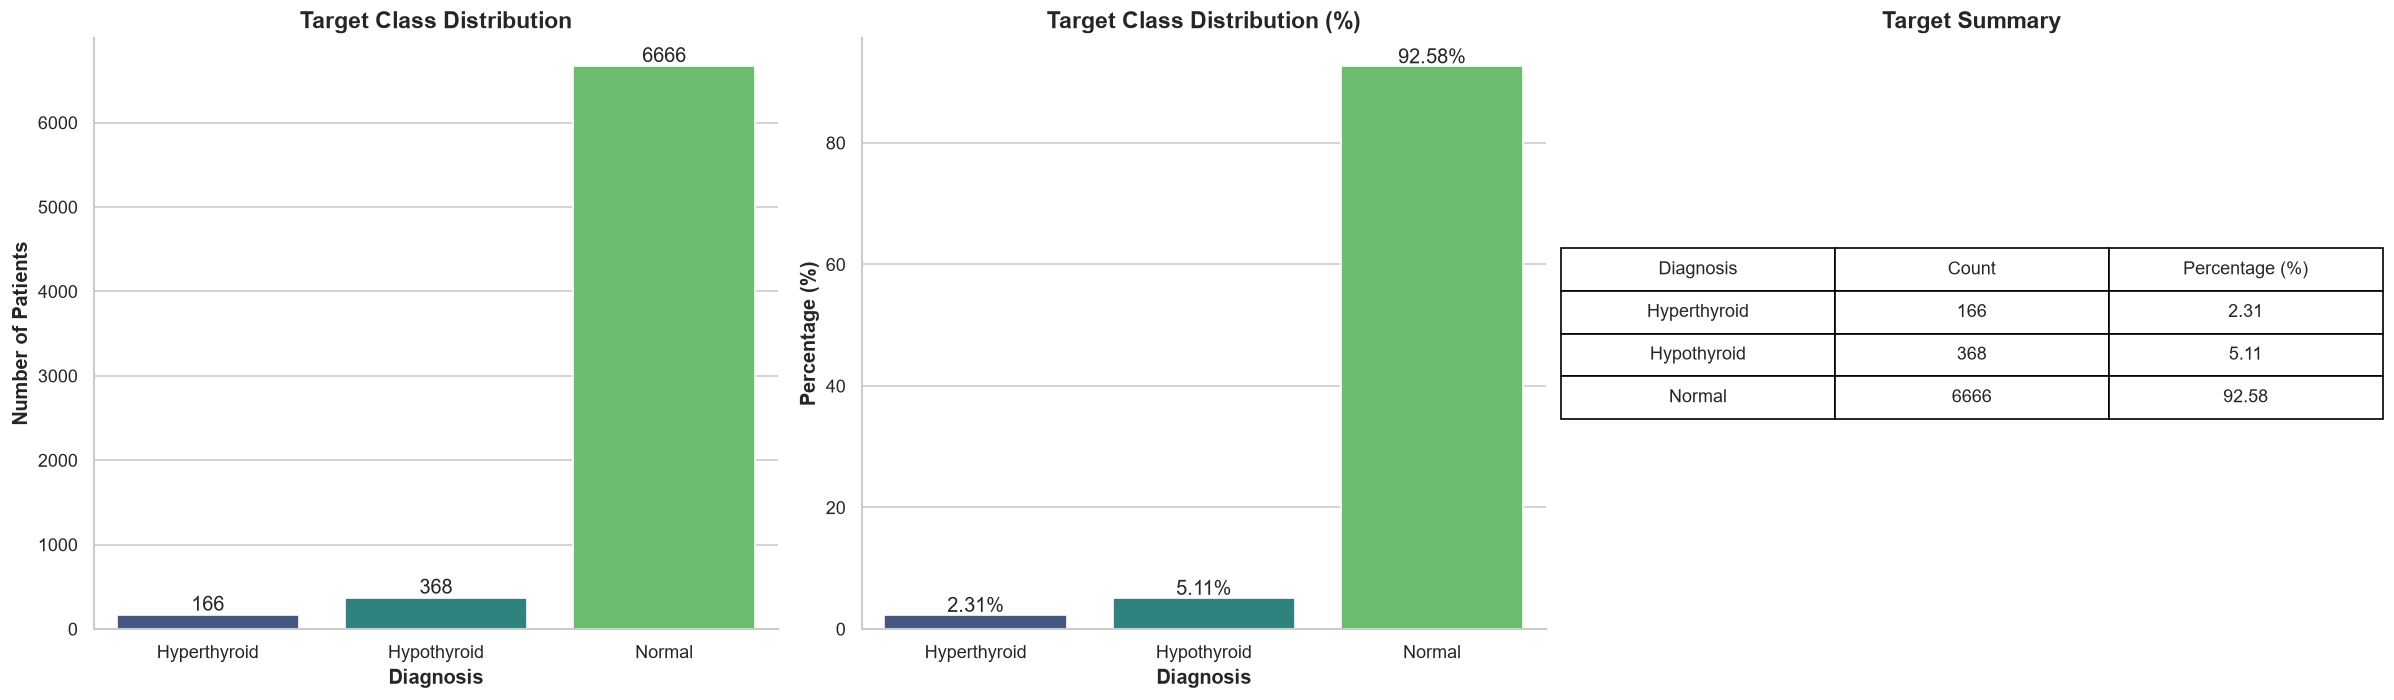

In [25]:
# Calculate class counts and percentages
class_counts = df["class"].value_counts().sort_index()
class_percentages = (class_counts / len(df) * 100).round(2)

target_summary = pd.DataFrame({
    "Diagnosis": ["Hyperthyroid", "Hypothyroid", "Normal"],
    "Count": class_counts.values,
    "Percentage (%)": class_percentages.values
})

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ---------------------------------
# Plot 1: Class Counts
# ---------------------------------
sns.countplot(
    data=df,
    x="class",
    order=[1, 2, 3],
    palette="viridis",
    ax=axes[0]
)

axes[0].set_title("Target Class Distribution")
axes[0].set_xlabel("Diagnosis")
axes[0].set_ylabel("Number of Patients")
axes[0].set_xticklabels(["Hyperthyroid", "Hypothyroid", "Normal"])

for p in axes[0].patches:
    axes[0].annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

# ---------------------------------
# Plot 2: Percentage Distribution
# ---------------------------------
sns.barplot(
    x=target_summary["Diagnosis"],
    y=target_summary["Percentage (%)"],
    palette="viridis",
    ax=axes[1]
)

axes[1].set_title("Target Class Distribution (%)")
axes[1].set_xlabel("Diagnosis")
axes[1].set_ylabel("Percentage (%)")

for i, value in enumerate(target_summary["Percentage (%)"]):
    axes[1].text(
        i,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

# ---------------------------------
# Plot 3: Summary Table
# ---------------------------------
axes[2].axis("off")

table = axes[2].table(
    cellText=target_summary.values,
    colLabels=target_summary.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)

axes[2].set_title("Target Summary")

plt.tight_layout()
plt.show()

The target variable is highly imbalanced, with the Normal class comprising 92.58% of the dataset, compared to only 5.11% for Hypothyroidism and 2.31% for Hyperthyroidism. This distribution indicates that disease cases, particularly Hyperthyroidism, are substantially underrepresented. As a result, machine learning models may become biased toward predicting the Normal class, leading to poor detection of the minority disease classes. Therefore, model performance will be evaluated using metrics that reflect performance across all classes rather than relying solely on overall accuracy.

### 3.3 Univariate Analysis

Univariate analysis examines each feature independently to understand its distribution, variability, and potential anomalies. Numerical variables are assessed using descriptive statistics and distribution plots, while binary variables are summarized using frequency distributions. The insights obtained from this analysis help identify skewness, outliers, and feature characteristics that may influence subsequent preprocessing and model development.

#### 3.3.1 Numerical Variables

##### Summary Statistics

In [26]:
# Numerical features
numerical_features = ["age", "TSH", "T3", "TT4", "T4U", "FTI"]

# Summary statistics
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,7200.0000,0.5205,0.1893,0.0100,0.3700,0.5500,0.6700,0.9700
TSH,7200.0000,0.0049,0.0230,0.0000,0.0007,0.0017,0.0027,0.5300
T3,7200.0000,0.0200,0.0075,0.0005,0.0170,0.0201,0.0220,0.1800
TT4,7200.0000,0.1094,0.0360,0.0020,0.0890,0.1070,0.1250,0.6000
T4U,7200.0000,0.0978,0.0191,0.0170,0.0870,0.0970,0.1040,0.2330
FTI,7200.0000,0.1132,0.0361,0.0020,0.0950,0.1110,0.1270,0.6420


##### Skewness

In [27]:
# Calculate skewness
skewness = pd.DataFrame({
    "Skewness": df[numerical_features].skew().round(3)
})

skewness

,Skewness
age,-0.2130
TSH,14.5260
T3,3.4880
TT4,1.5160
T4U,1.2480
FTI,2.3850


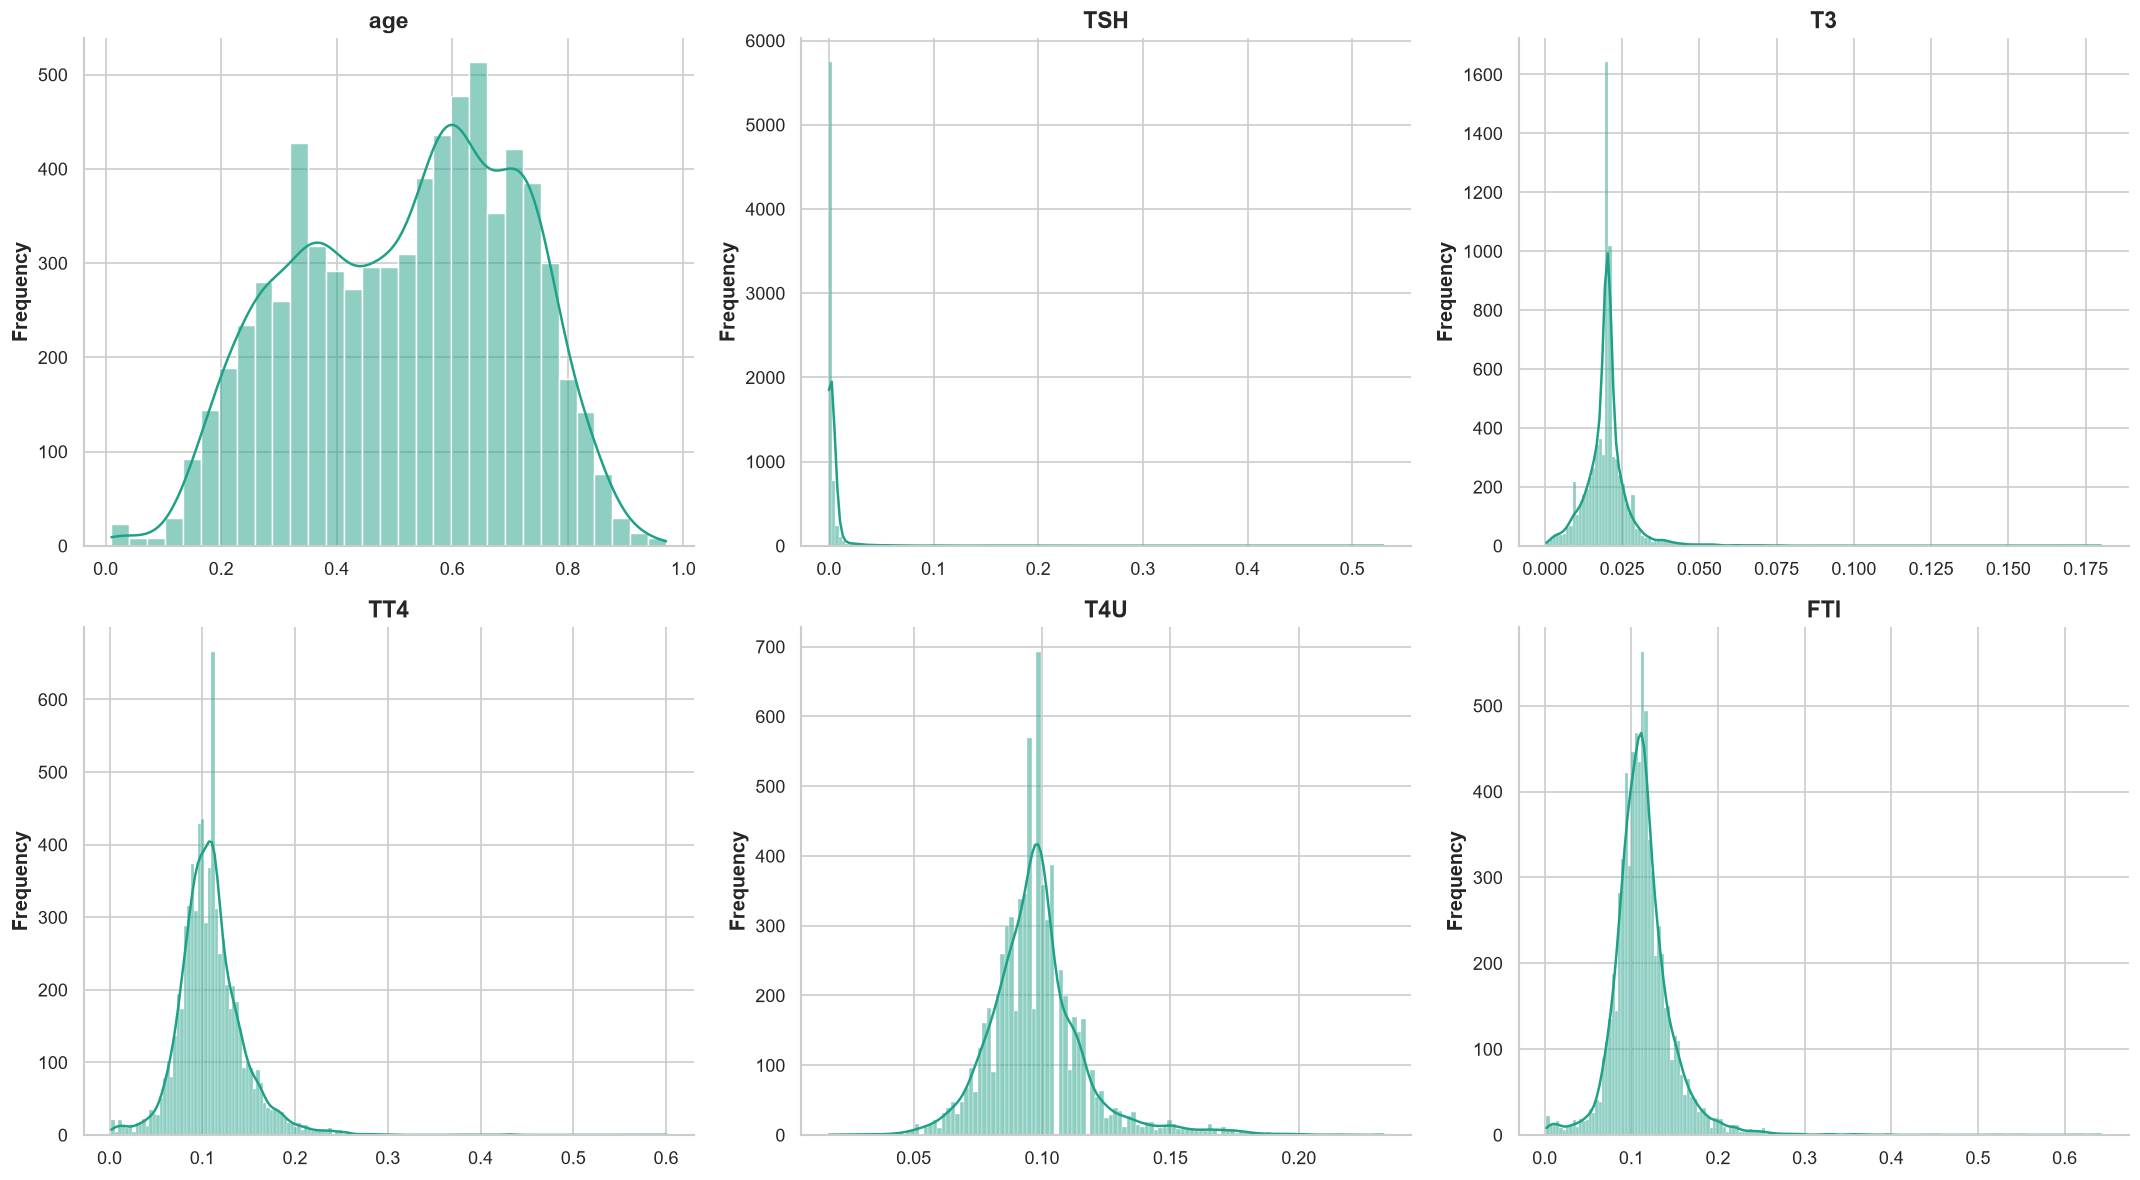

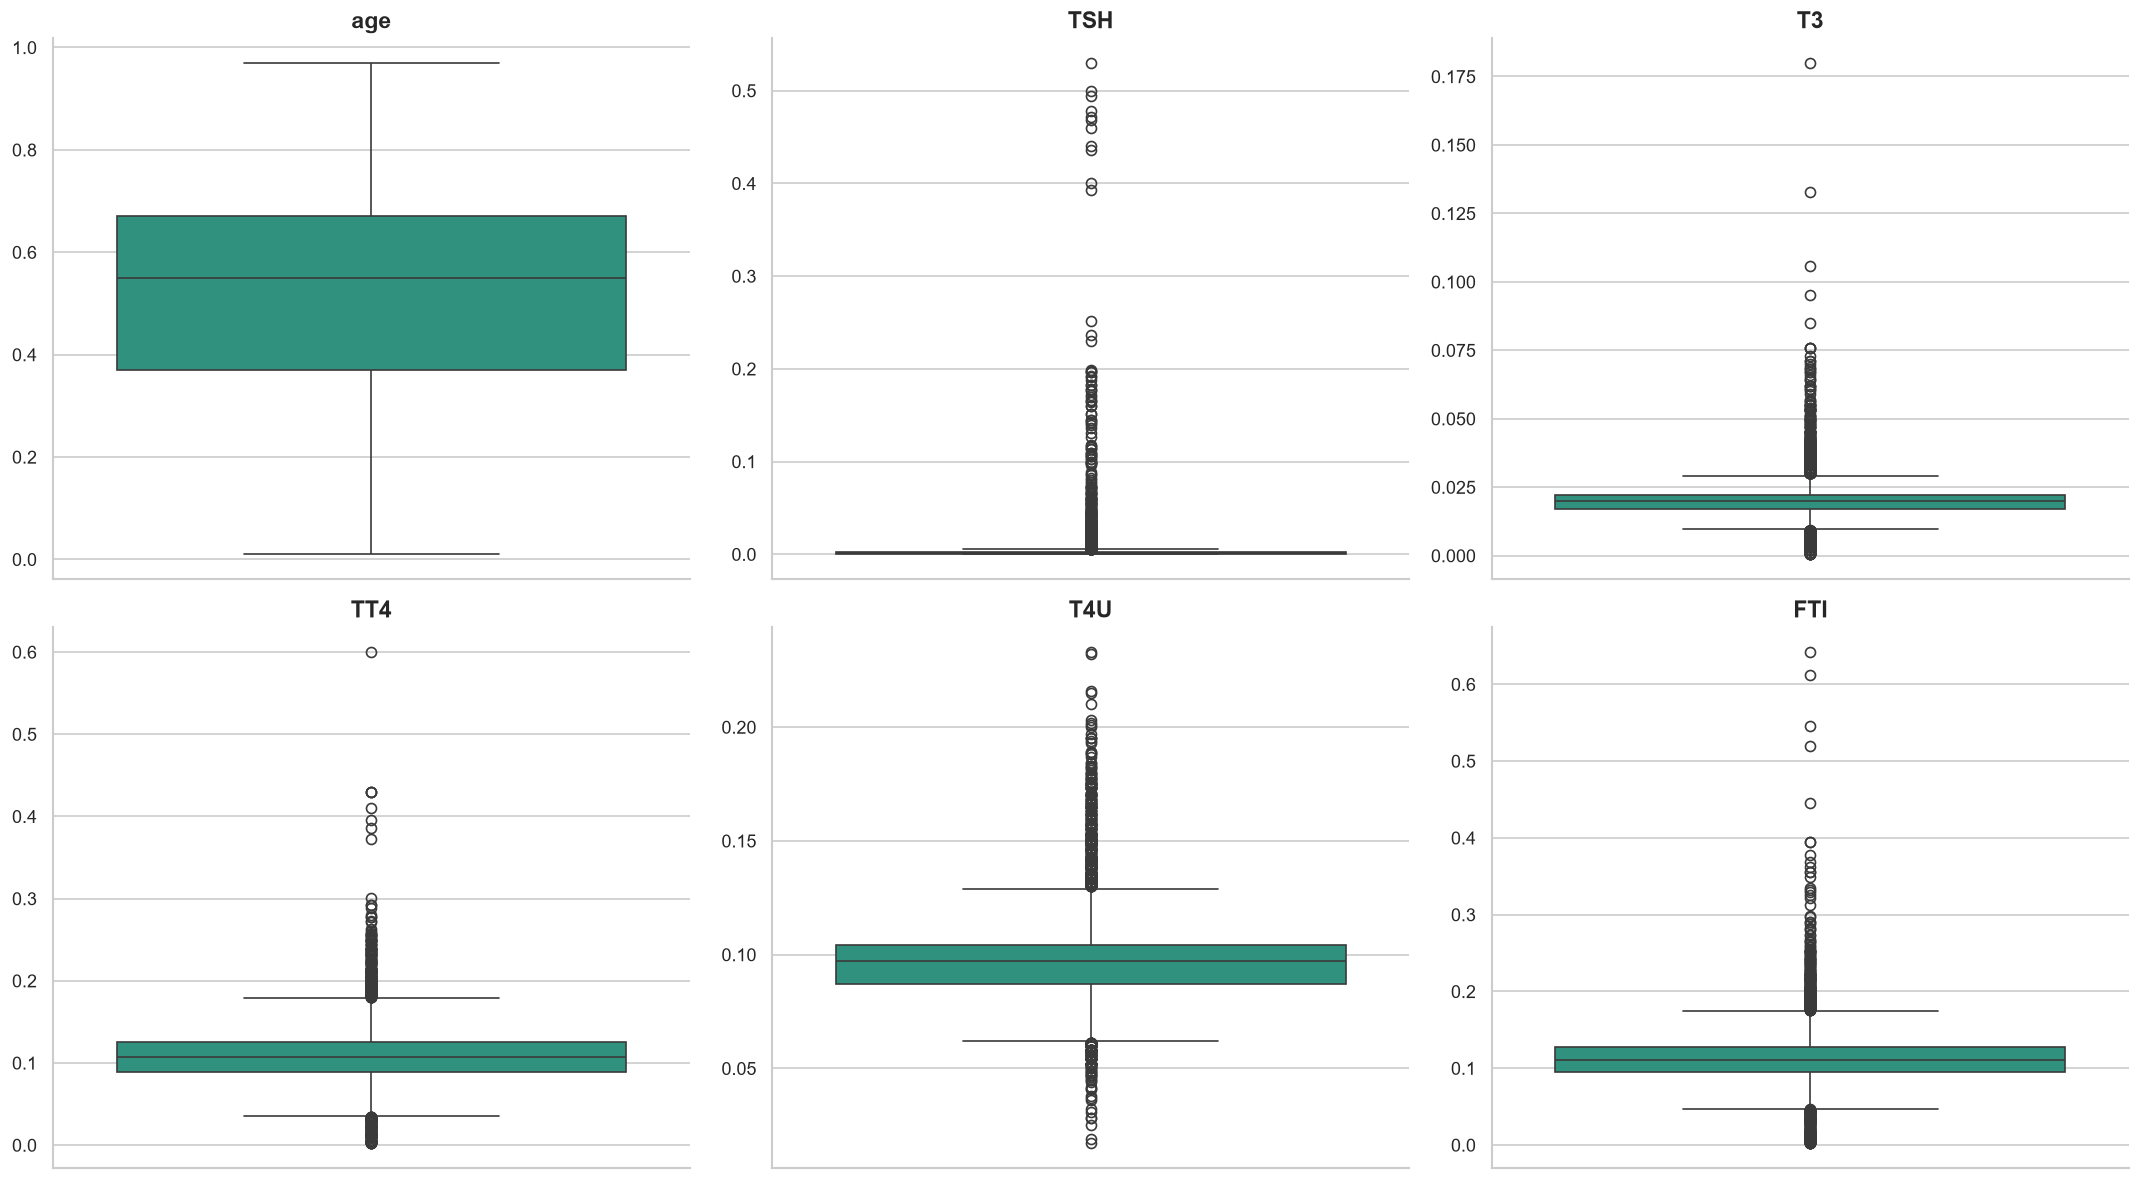

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feature in zip(axes.flatten(), numerical_features):

    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        ax=ax,
        color=sns.color_palette("viridis")[3]
    )

    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feature in zip(axes.flatten(), numerical_features):

    sns.boxplot(
        y=df[feature],
        ax=ax,
        color=sns.color_palette("viridis")[3]
    )

    ax.set_title(feature)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

The numerical variables exhibit diverse distributional characteristics. The age variable displays a relatively broad distribution with no pronounced skewness, suggesting a good representation of patients across different age groups. In contrast, the laboratory measurements (TSH, T3, TT4, T4U, and FTI) are generally positively skewed, with most observations concentrated within a narrow range and a small number of extreme values extending the upper tails of their distributions. The corresponding boxplots confirm the presence of numerous outliers, particularly for TSH, TT4, and FTI, while age shows comparatively few extreme observations. These outliers are likely to reflect genuine physiological variations rather than data entry errors, given the clinical nature of the dataset. Consequently, they will be retained during preprocessing, and any necessary feature scaling or transformation will be considered during model development rather than removing potentially informative observations.

### Binary Variables

##### Frequency Distribution

In [31]:
binary_features = [
    "sex",
    "on_thyroxine",
    "query_on_thyroxine",
    "on_antithyroid_medication",
    "sick",
    "pregnant",
    "thyroid_surgery",
    "I131_treatment",
    "query_hypothyroid",
    "query_hyperthyroid",
    "lithium",
    "goitre",
    "tumor",
    "hypopituitary",
    "psych"
]

binary_summary = pd.DataFrame({
    "Count (Yes)": df[binary_features].sum(),
    "Percentage (%)": (df[binary_features].mean()*100).round(2)
})

binary_summary.sort_values(
    by="Percentage (%)",
    ascending=False
)

,Count (Yes),Percentage (%)
sex,2191,30.4300
on_thyroxine,940,13.0600
query_hyperthyroid,495,6.8800
query_hypothyroid,472,6.5600
psych,352,4.8900
sick,276,3.8300
tumor,184,2.5600
I131_treatment,121,1.6800
query_on_thyroxine,111,1.5400
thyroid_surgery,101,1.4000


##### Binary Variables Distribution

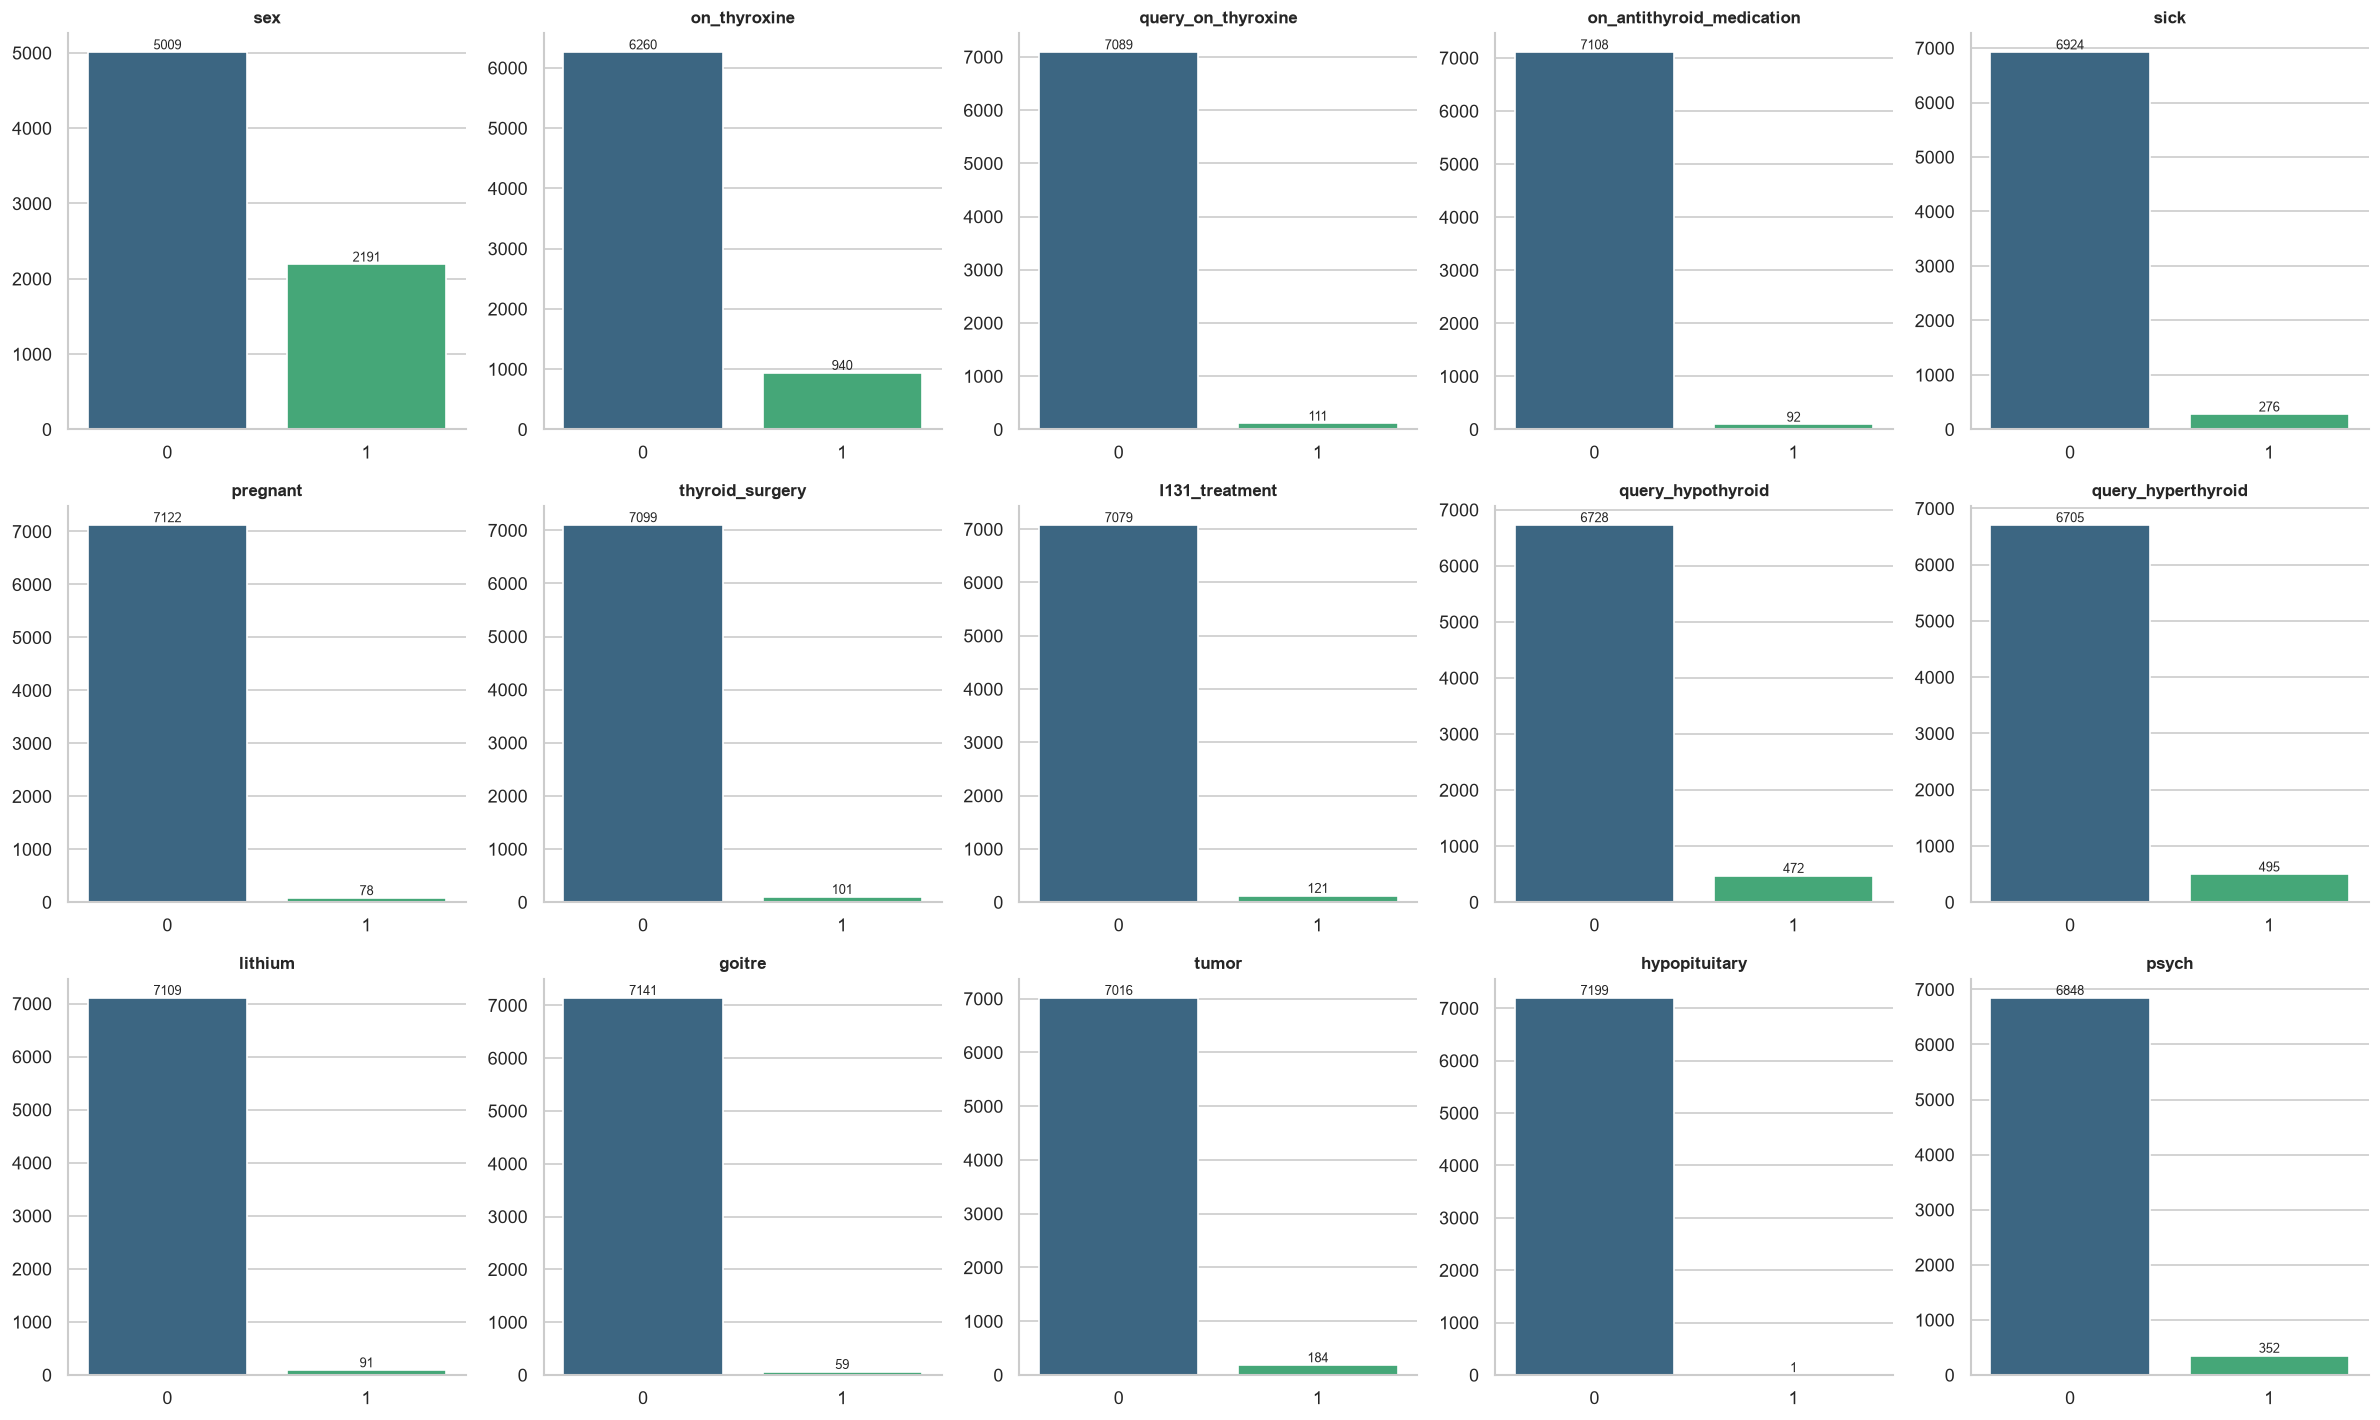

In [32]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))

for ax, feature in zip(axes.flatten(), binary_features):

    sns.countplot(
        data=df,
        x=feature,
        palette="viridis",
        ax=ax
    )

    ax.set_title(feature, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

    for p in ax.patches:
        ax.annotate(
            int(p.get_height()),
            (p.get_x() + p.get_width()/2,
             p.get_height()),
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()
plt.show()

The binary variables are predominantly characterized by the absence of the recorded clinical condition or treatment (value = 0), indicating that most patients did not exhibit these characteristics. The most prevalent binary feature is sex, with females (coded as 0) representing the majority of the study population. Among the clinical indicators, query_hyperthyroid (495 cases), query_hypothyroid (472 cases), psych (352 cases), and sick (276 cases) have relatively higher frequencies of positive observations compared to the remaining variables. Conversely, features such as hypopituitary (1 case), goitre (59 cases), pregnant (78 cases), lithium (91 cases), on_antithyroid_medication (92 cases), and thyroid_surgery (101 cases) are extremely rare. The substantial imbalance observed across several binary predictors suggests that while these variables may contain clinically relevant information, some contribute limited variability and may have a smaller influence on model performance.